# Análise e Calibração de Constantes do Sistema (Potência)

Este notebook tem como objetivo realizar a calibração das constantes teóricas ($\alpha$, $\gamma$) do modelo de potência, utilizando os dados de tensão e frequência extraídos das rodadas de treinamento.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import glob
import json
import ast
import math
import os

# Configurações do matplotlib
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carregamento dos Dados
Lê os dados da pasta `data_tensao` e os concatena em um único DataFrame.
Garante que os dados de `staX_datasz` sejam preenchidos para todas as linhas antes de descartar a primeira linha e deletar as colunas `consumption_staX`.

In [3]:
data_path = 'data_tensao'
all_files = sorted(glob.glob(os.path.join(data_path, "*.csv")))
df_list = []
for f in all_files:
    df_tmp = pd.read_csv(f)
    
    # Preenche (forward fill) os tamanhos de dados ('staX_datasz') 
    # já que eles aparecem apenas na primeira linha
    datasz_cols = [c for c in df_tmp.columns if c.endswith('_datasz')]
    df_tmp[datasz_cols] = df_tmp[datasz_cols].ffill()
    
    # Agora ignora a primeira linha de dados
    df_tmp = df_tmp.iloc[1:]
    df_list.append(df_tmp)

if len(df_list) > 0:
    df = pd.concat(df_list, ignore_index=True)
    
    # Deletar (drop) as colunas indesejadas 'consumption_staX'
    cols_to_drop = [c for c in df.columns if c.startswith('consumption_sta')]
    df = df.drop(columns=cols_to_drop)
    
    print(f"Total de amostras carregadas: {len(df)}")
    print(f"Arquivos lidos: {[os.path.basename(f) for f in all_files]}")
else:
    print("Nenhum arquivo CSV encontrado na pasta data_tensao.")
    df = pd.DataFrame()

Total de amostras carregadas: 295
Arquivos lidos: ['calibrar_alpha_10.csv', 'calibrar_alpha_6.csv', 'calibrar_alpha_7.csv', 'calibrar_alpha_8.csv', 'calibrar_alpha_9.csv']


## 2. Processamento e Limpeza
Extrai e formata as colunas, especialmente `cpus_freqs_staX` que vem como string de lista, calculando a frequência média de operação da CPU.
Converte todas as colunas numéricas para o tipo correto.

**Conversão de unidades:**
- `host_consumption_staX`: $\mu J \rightarrow J$ (÷ $10^6$)
- `cpu_freq_mean_staX`: $GHz \rightarrow Hz$ (× $10^9$)

In [4]:
N = 11  # Número de estações (0 a 10)

# Função para extrair a média das frequências (string para lista para média)
def parse_freqs(freq_str):
    try:
        if pd.isna(freq_str):
            return np.nan
        freq_list = ast.literal_eval(str(freq_str))
        return np.mean(freq_list)
    except:
        return np.nan

# Dicionário para armazenar os DataFrames isolados por estação
df_sta = {}

if not df.empty:
    for i in range(N):
        cols = [
            f'sta{i}_datasz', 
            f'training_time_sta{i}', 
            f'host_consumption_sta{i}', 
            f'cpu_voltage_sta{i}', 
            f'cpus_freqs_sta{i}'
        ]
        # Pegar apenas colunas que existem no DataFrame
        cols_present = [c for c in cols if c in df.columns]
        
        df_tmp = df[cols_present].copy()
        
        # Converter colunas numéricas para o tipo correto
        for col in cols_present:
            if col != f'cpus_freqs_sta{i}':  # freqs é string/lista
                df_tmp[col] = pd.to_numeric(df_tmp[col], errors='coerce')
        
        if f'cpus_freqs_sta{i}' in df_tmp.columns:
            df_tmp[f'cpu_freq_mean_sta{i}'] = df_tmp[f'cpus_freqs_sta{i}'].apply(parse_freqs)
            
        df_tmp = df_tmp.dropna()
        
        # Conversão de unidades
        # Energia: µJ -> J (dividir por 1e6)
        if f'host_consumption_sta{i}' in df_tmp.columns:
            df_tmp[f'host_consumption_sta{i}'] = df_tmp[f'host_consumption_sta{i}'] / (1e6*11)
        # Frequência: GHz -> Hz (multiplicar por 1e9)
        if f'cpu_freq_mean_sta{i}' in df_tmp.columns:
            df_tmp[f'cpu_freq_mean_sta{i}'] = df_tmp[f'cpu_freq_mean_sta{i}'] * 1e9
        
        df_sta[i] = df_tmp
        print(f"$DC_{{{i}}}$: {len(df_tmp)} amostras válidas")

$DC_{0}$: 295 amostras válidas
$DC_{1}$: 295 amostras válidas
$DC_{2}$: 295 amostras válidas
$DC_{3}$: 295 amostras válidas
$DC_{4}$: 295 amostras válidas
$DC_{5}$: 295 amostras válidas
$DC_{6}$: 295 amostras válidas
$DC_{7}$: 295 amostras válidas
$DC_{8}$: 295 amostras válidas
$DC_{9}$: 295 amostras válidas
$DC_{10}$: 295 amostras válidas


## 3. Análise Exploratória (Gráficos)
Visualização da relação entre o Consumo/Potência (`host_consumption / training_time`), Tensão e Frequência para cada estação.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


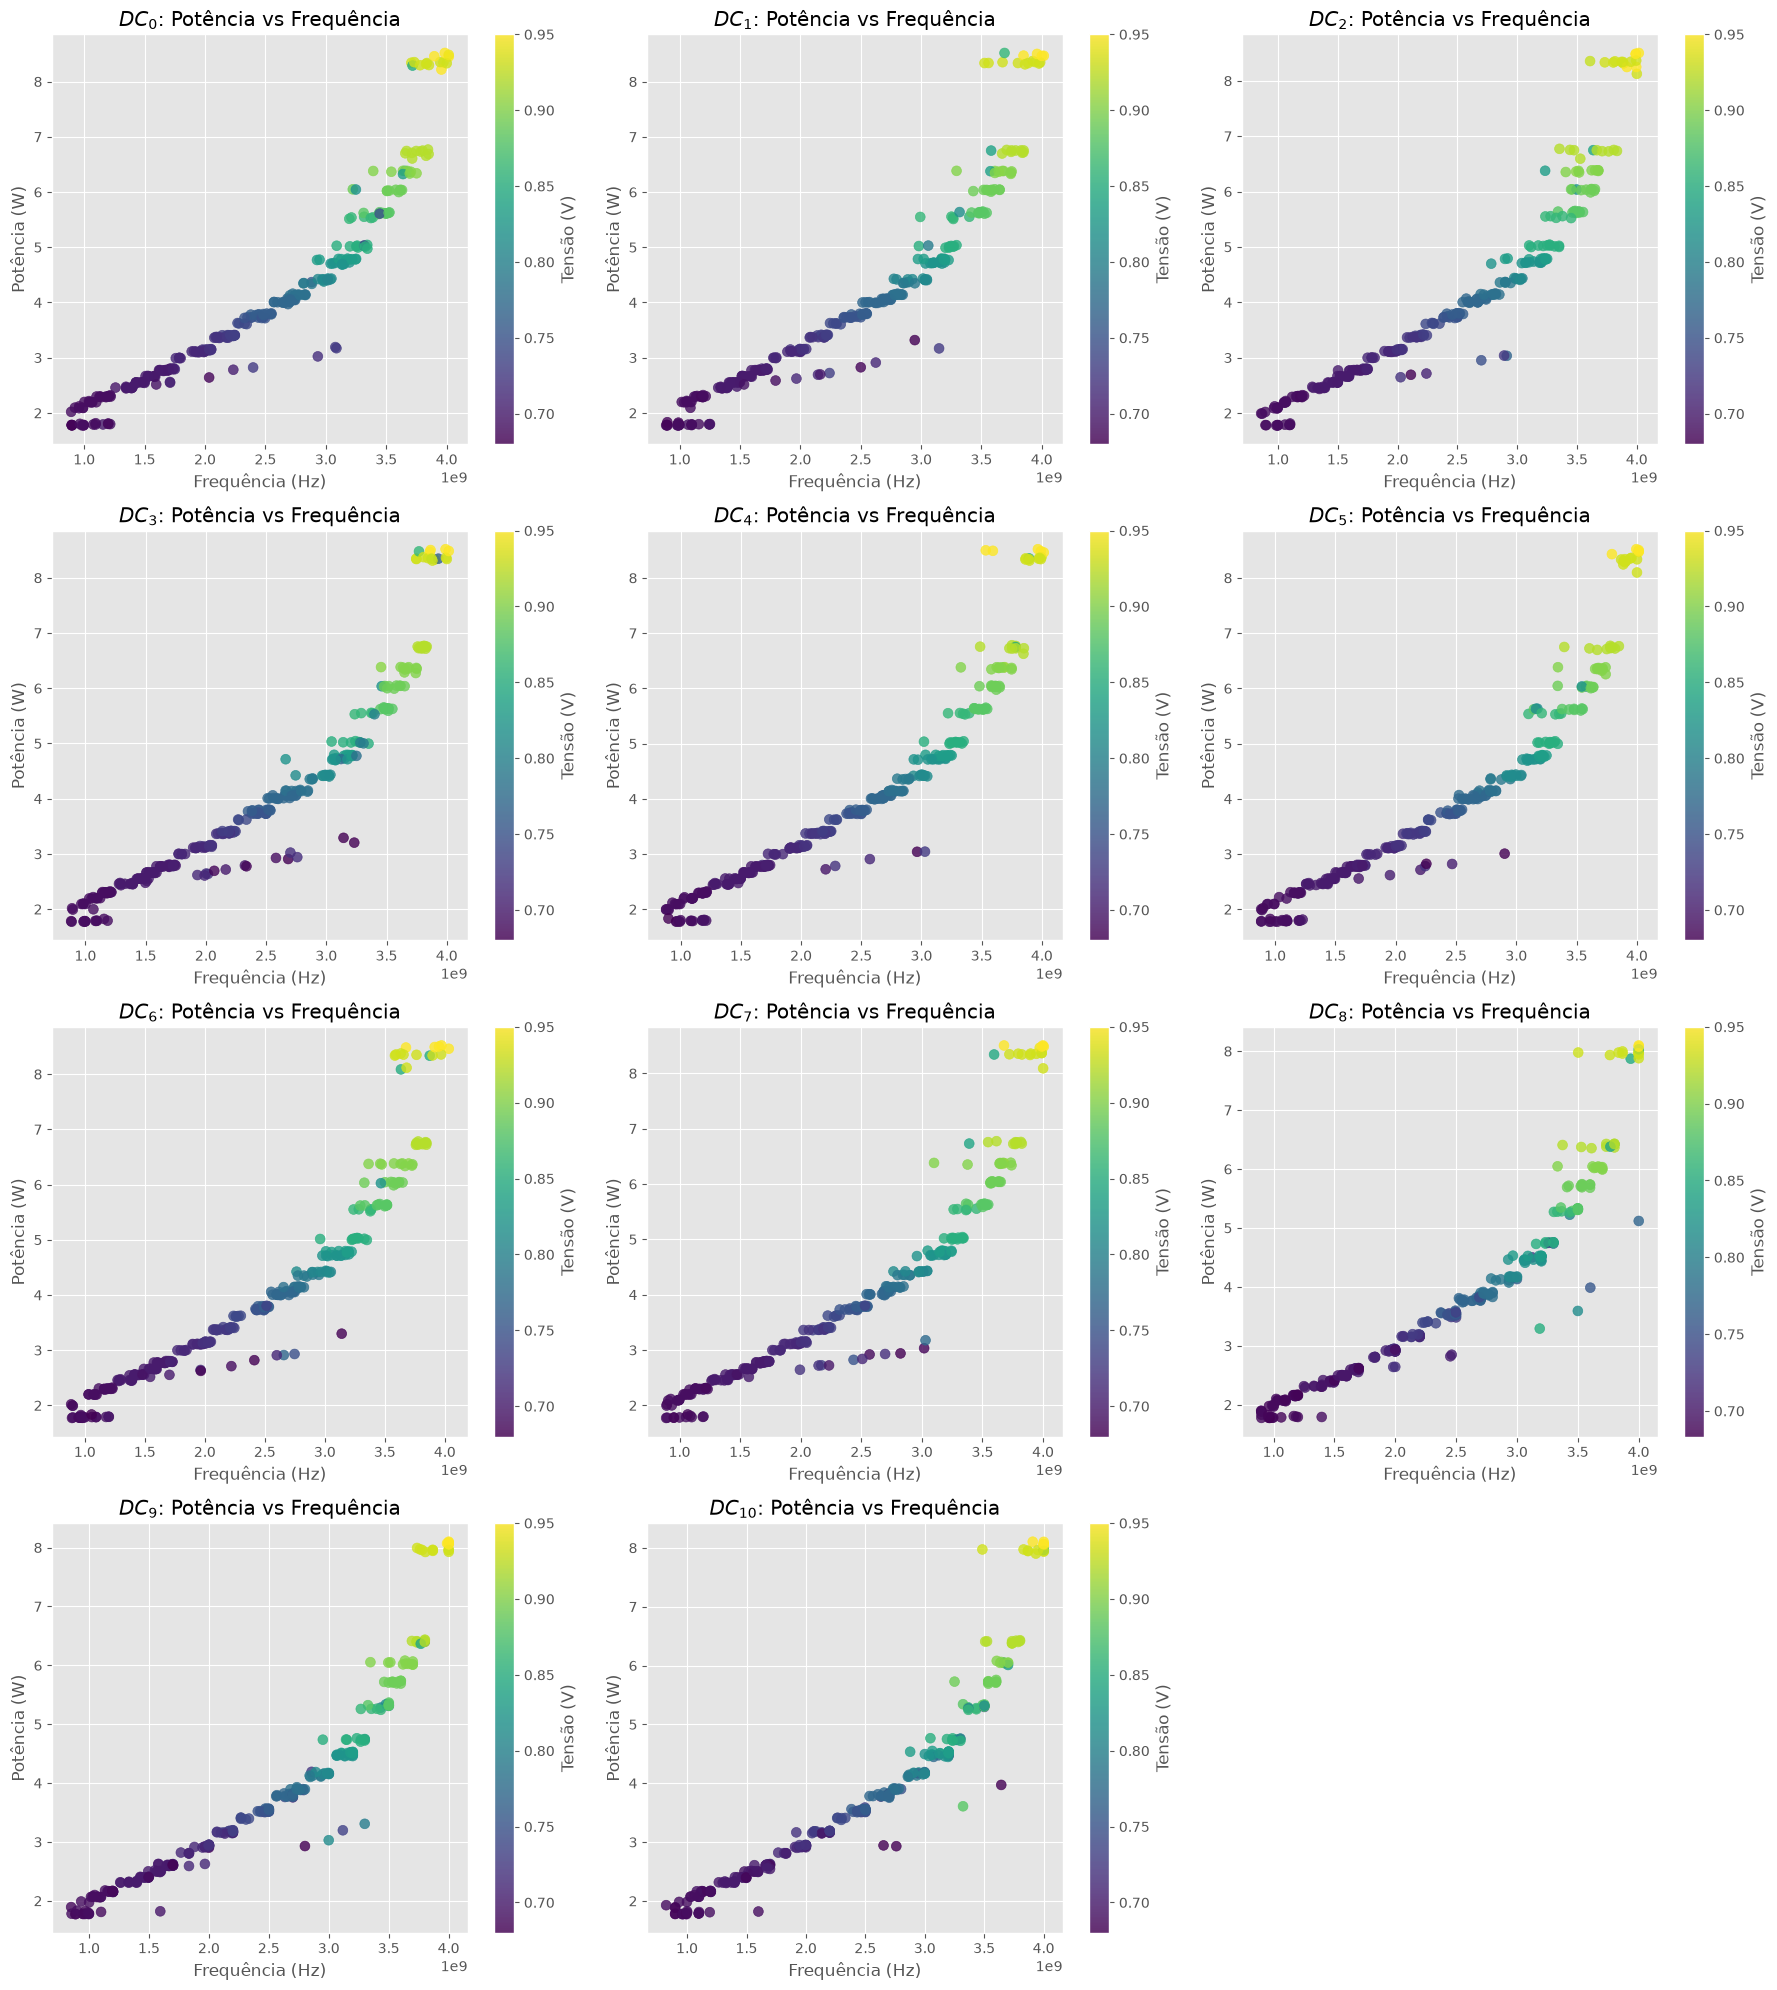

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


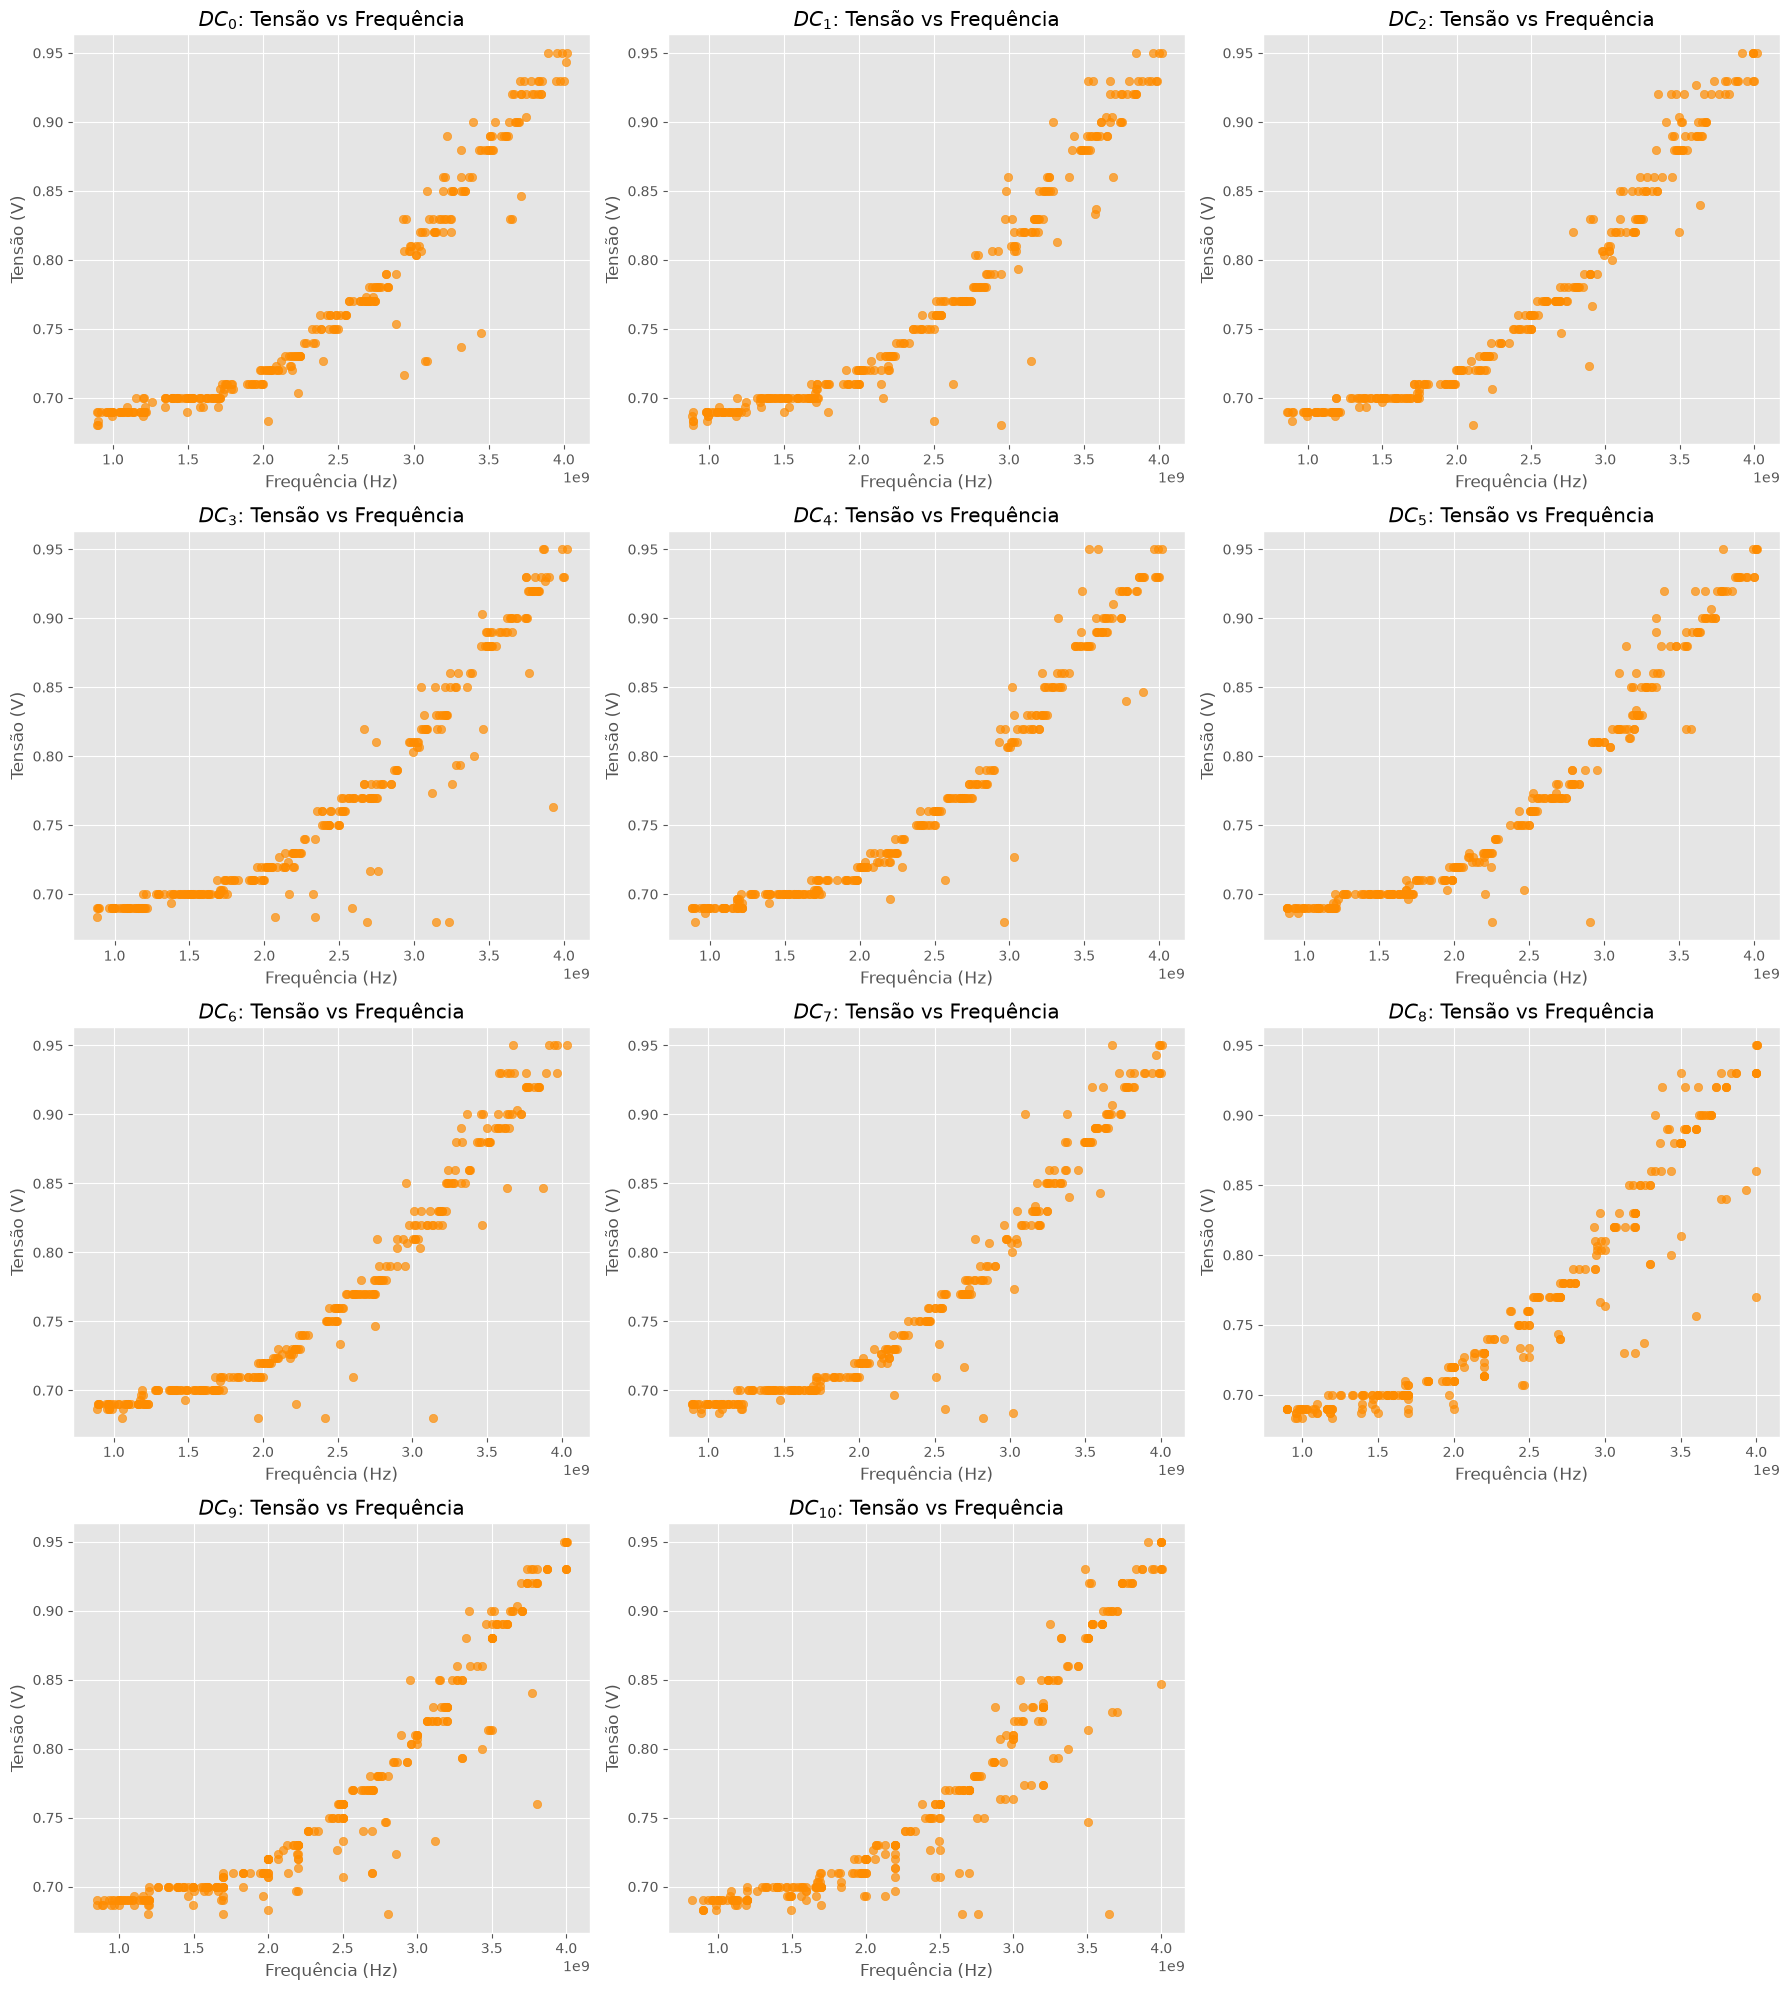

In [5]:
stations_with_data = [i for i in range(N) if i in df_sta and not df_sta[i].empty]
num_stations = len(stations_with_data)

if num_stations > 0:
    cols_plot = 3
    rows_plot = math.ceil(num_stations / cols_plot)
    
    # --- 1. Gráficos de Potência vs Frequência (com Tensão no colormap) ---
    fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(18, 5 * rows_plot))
    axes = axes.flatten() if num_stations > 1 else [axes]
    
    for idx, i in enumerate(stations_with_data):
        ax = axes[idx]
        df_i = df_sta[i]
        
        if f'host_consumption_sta{i}' in df_i.columns and f'training_time_sta{i}' in df_i.columns:
            # Potência = Energia (J) / Tempo (s) = Watts
            power = df_i[f'host_consumption_sta{i}'] / df_i[f'training_time_sta{i}']
            freq = df_i[f'cpu_freq_mean_sta{i}']
            volt = df_i[f'cpu_voltage_sta{i}']
            
            sc = ax.scatter(freq, power, c=volt, cmap='viridis', s=50, alpha=0.8)
            ax.set_title(f'$DC_{{{i}}}$: Potência vs Frequência')
            ax.set_xlabel('Frequência (Hz)')
            ax.set_ylabel('Potência (W)')
            fig.colorbar(sc, ax=ax, label='Tensão (V)')
            
    # Remover subplots vazios
    for idx in range(num_stations, len(axes)):
        fig.delaxes(axes[idx])
        
    plt.tight_layout()
    plt.savefig('fit_alpha_plot_1.eps', format='eps', bbox_inches='tight')
    plt.show()

    # --- 2. Gráficos de Tensão vs Frequência ---
    fig2, axes2 = plt.subplots(rows_plot, cols_plot, figsize=(18, 5 * rows_plot))
    axes2 = axes2.flatten() if num_stations > 1 else [axes2]
    
    for idx, i in enumerate(stations_with_data):
        ax = axes2[idx]
        df_i = df_sta[i]
        
        freq = df_i[f'cpu_freq_mean_sta{i}']
        volt = df_i[f'cpu_voltage_sta{i}']
        
        ax.scatter(freq, volt, color='darkorange', alpha=0.7)
        ax.set_title(f'$DC_{{{i}}}$: Tensão vs Frequência')
        ax.set_xlabel('Frequência (Hz)')
        ax.set_ylabel('Tensão (V)')
        
    # Remover subplots vazios
    for idx in range(num_stations, len(axes2)):
        fig2.delaxes(axes2[idx])
        
    plt.tight_layout()
    plt.savefig('fit_alpha_plot_2.eps', format='eps', bbox_inches='tight')
    plt.show()

## 4. Diagnóstico dos Dados para Calibração
Antes de ajustar o modelo, verificar a escala e variação das variáveis de entrada.

In [6]:
for i in stations_with_data:
    df_i = df_sta[i]
    P = df_i[f'host_consumption_sta{i}'] / df_i[f'training_time_sta{i}']
    f_vals = df_i[f'cpu_freq_mean_sta{i}']
    V_vals = df_i[f'cpu_voltage_sta{i}']
    print(f"--- $DC_{{{i}}}$ ---")
    print(f"  P (Potência) [W]:     min={P.min():.4f}, max={P.max():.4f}, mean={P.mean():.4f}")
    print(f"  f (Frequência) [Hz]:  min={f_vals.min():.2f}, max={f_vals.max():.2f}, std={f_vals.std():.2f}")
    print(f"  V (Tensão) [V]:       min={V_vals.min():.4f}, max={V_vals.max():.4f}, std={V_vals.std():.4f}")
    print()

--- $DC_{0}$ ---
  P (Potência) [W]:     min=1.7733, max=8.5182, mean=3.9951
  f (Frequência) [Hz]:  min=892000000.00, max=4017500000.00, std=896510749.08
  V (Tensão) [V]:       min=0.6800, max=0.9500, std=0.0787

--- $DC_{1}$ ---
  P (Potência) [W]:     min=1.7731, max=8.5195, mean=3.9918
  f (Frequência) [Hz]:  min=887000000.00, max=4017000000.00, std=891230747.09
  V (Tensão) [V]:       min=0.6800, max=0.9500, std=0.0791

--- $DC_{2}$ ---
  P (Potência) [W]:     min=1.7764, max=8.5023, mean=4.0097
  f (Frequência) [Hz]:  min=858000000.00, max=4017000000.00, std=890554883.55
  V (Tensão) [V]:       min=0.6800, max=0.9500, std=0.0793

--- $DC_{3}$ ---
  P (Potência) [W]:     min=1.7726, max=8.5176, mean=3.9855
  f (Frequência) [Hz]:  min=881500000.00, max=4017000000.00, std=898051905.13
  V (Tensão) [V]:       min=0.6800, max=0.9500, std=0.0791

--- $DC_{4}$ ---
  P (Potência) [W]:     min=1.7748, max=8.5199, mean=4.0082
  f (Frequência) [Hz]:  min=879000000.00, max=4016000000.00, st

## 5. Calibração do Modelo de Potência ($\alpha, \gamma$)
Modelo: $P_i = (1 + \gamma \cdot V) \cdot \alpha \cdot f_i \cdot V^2$

Usaremos a potência $P_i = E_i / T_i$, onde $E_i$ é a energia em Joules e $T_i$ o tempo em segundos.

O chute inicial para `alpha` é estimado com base na escala dos dados observados.

**Nota:** O parâmetro $\gamma$ não é restrito a valores positivos, pois ele pode assumir valores negativos dependendo da arquitetura.

In [7]:
def power_model(X, alpha, gamma):
    f, V = X
    return (1 + gamma * V) * alpha * f * (V**2)

alpha_calibrated = np.zeros(N)
gamma_calibrated = np.zeros(N)
fit_results = {}

if not df.empty:
    for i in stations_with_data:
        df_i = df_sta[i]
        if f'host_consumption_sta{i}' not in df_i.columns or f'cpu_freq_mean_sta{i}' not in df_i.columns:
            continue
            
        # Potência Média = Energia (J) / Tempo (s) = Watts
        P_data = (df_i[f'host_consumption_sta{i}'] / df_i[f'training_time_sta{i}']).values.astype(float)
        f_data = df_i[f'cpu_freq_mean_sta{i}'].values.astype(float)
        V_data = df_i[f'cpu_voltage_sta{i}'].values.astype(float)
        
        # Estimar chute inicial para alpha:
        # P ≈ alpha * f * V^2  (ignorando gamma por simplicidade)
        # alpha_est ≈ P_mean / (f_mean * V_mean^2)
        P_mean = np.mean(P_data)
        f_mean = np.mean(f_data)
        V_mean = np.mean(V_data)
        alpha_est = P_mean / (f_mean * V_mean**2) if (f_mean * V_mean**2) > 0 else 1.0
        
        try:
            popt, pcov = curve_fit(
                power_model, 
                (f_data, V_data), 
                P_data, 
                p0=[alpha_est, 1.0],
                # alpha > 0, gamma sem restrição (pode ser negativo)
                bounds=([0, -np.inf], [np.inf, np.inf]),
                maxfev=50000
            )
            alpha_calibrated[i] = popt[0]
            gamma_calibrated[i] = popt[1]
            
            # Erros padrão dos parâmetros
            perr = np.sqrt(np.diag(pcov))
            
            # Calcular R² para avaliar a qualidade do ajuste
            P_pred = power_model((f_data, V_data), *popt)
            ss_res = np.sum((P_data - P_pred)**2)
            ss_tot = np.sum((P_data - np.mean(P_data))**2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            fit_results[i] = {'alpha': popt[0], 'gamma': popt[1], 'R2': r_squared,
                              'alpha_err': perr[0], 'gamma_err': perr[1]}
            print(f"$DC_{{{i}}}$: alpha={popt[0]:.6e} ± {perr[0]:.2e}, gamma={popt[1]:.6f} ± {perr[1]:.6f}, R²={r_squared:.6f}")
        except Exception as e:
            print(f"$DC_{{{i}}}$: FALHA na calibração - {e}")

print("\n--- Resumo ---")
print(f"Alpha Calibrado: {alpha_calibrated}")
print(f"Gamma Calibrado: {gamma_calibrated}")

$DC_{0}$: alpha=5.128202e-09 ± 1.92e-10, gamma=-0.626739 ± 0.020546, R²=0.904154
$DC_{1}$: alpha=5.060078e-09 ± 1.95e-10, gamma=-0.618614 ± 0.021435, R²=0.905099
$DC_{2}$: alpha=5.079876e-09 ± 1.95e-10, gamma=-0.620191 ± 0.021242, R²=0.902661
$DC_{3}$: alpha=5.184749e-09 ± 1.94e-10, gamma=-0.633038 ± 0.020434, R²=0.900460
$DC_{4}$: alpha=5.133083e-09 ± 1.96e-10, gamma=-0.628991 ± 0.020838, R²=0.902526
$DC_{5}$: alpha=5.118803e-09 ± 1.80e-10, gamma=-0.627526 ± 0.019187, R²=0.917008
$DC_{6}$: alpha=5.094735e-09 ± 2.02e-10, gamma=-0.622005 ± 0.021929, R²=0.898406
$DC_{7}$: alpha=5.055748e-09 ± 2.03e-10, gamma=-0.621119 ± 0.022171, R²=0.894709
$DC_{8}$: alpha=4.878511e-09 ± 1.87e-10, gamma=-0.629680 ± 0.021275, R²=0.897635
$DC_{9}$: alpha=4.794860e-09 ± 1.80e-10, gamma=-0.618264 ± 0.021009, R²=0.902952
$DC_{10}$: alpha=4.912316e-09 ± 1.74e-10, gamma=-0.629909 ± 0.019421, R²=0.907805

--- Resumo ---
Alpha Calibrado: [5.12820167e-09 5.06007806e-09 5.07987625e-09 5.18474874e-09
 5.13308272e-0

## 6. Visualização do Ajuste
Comparar os dados observados com o modelo calibrado para cada estação.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


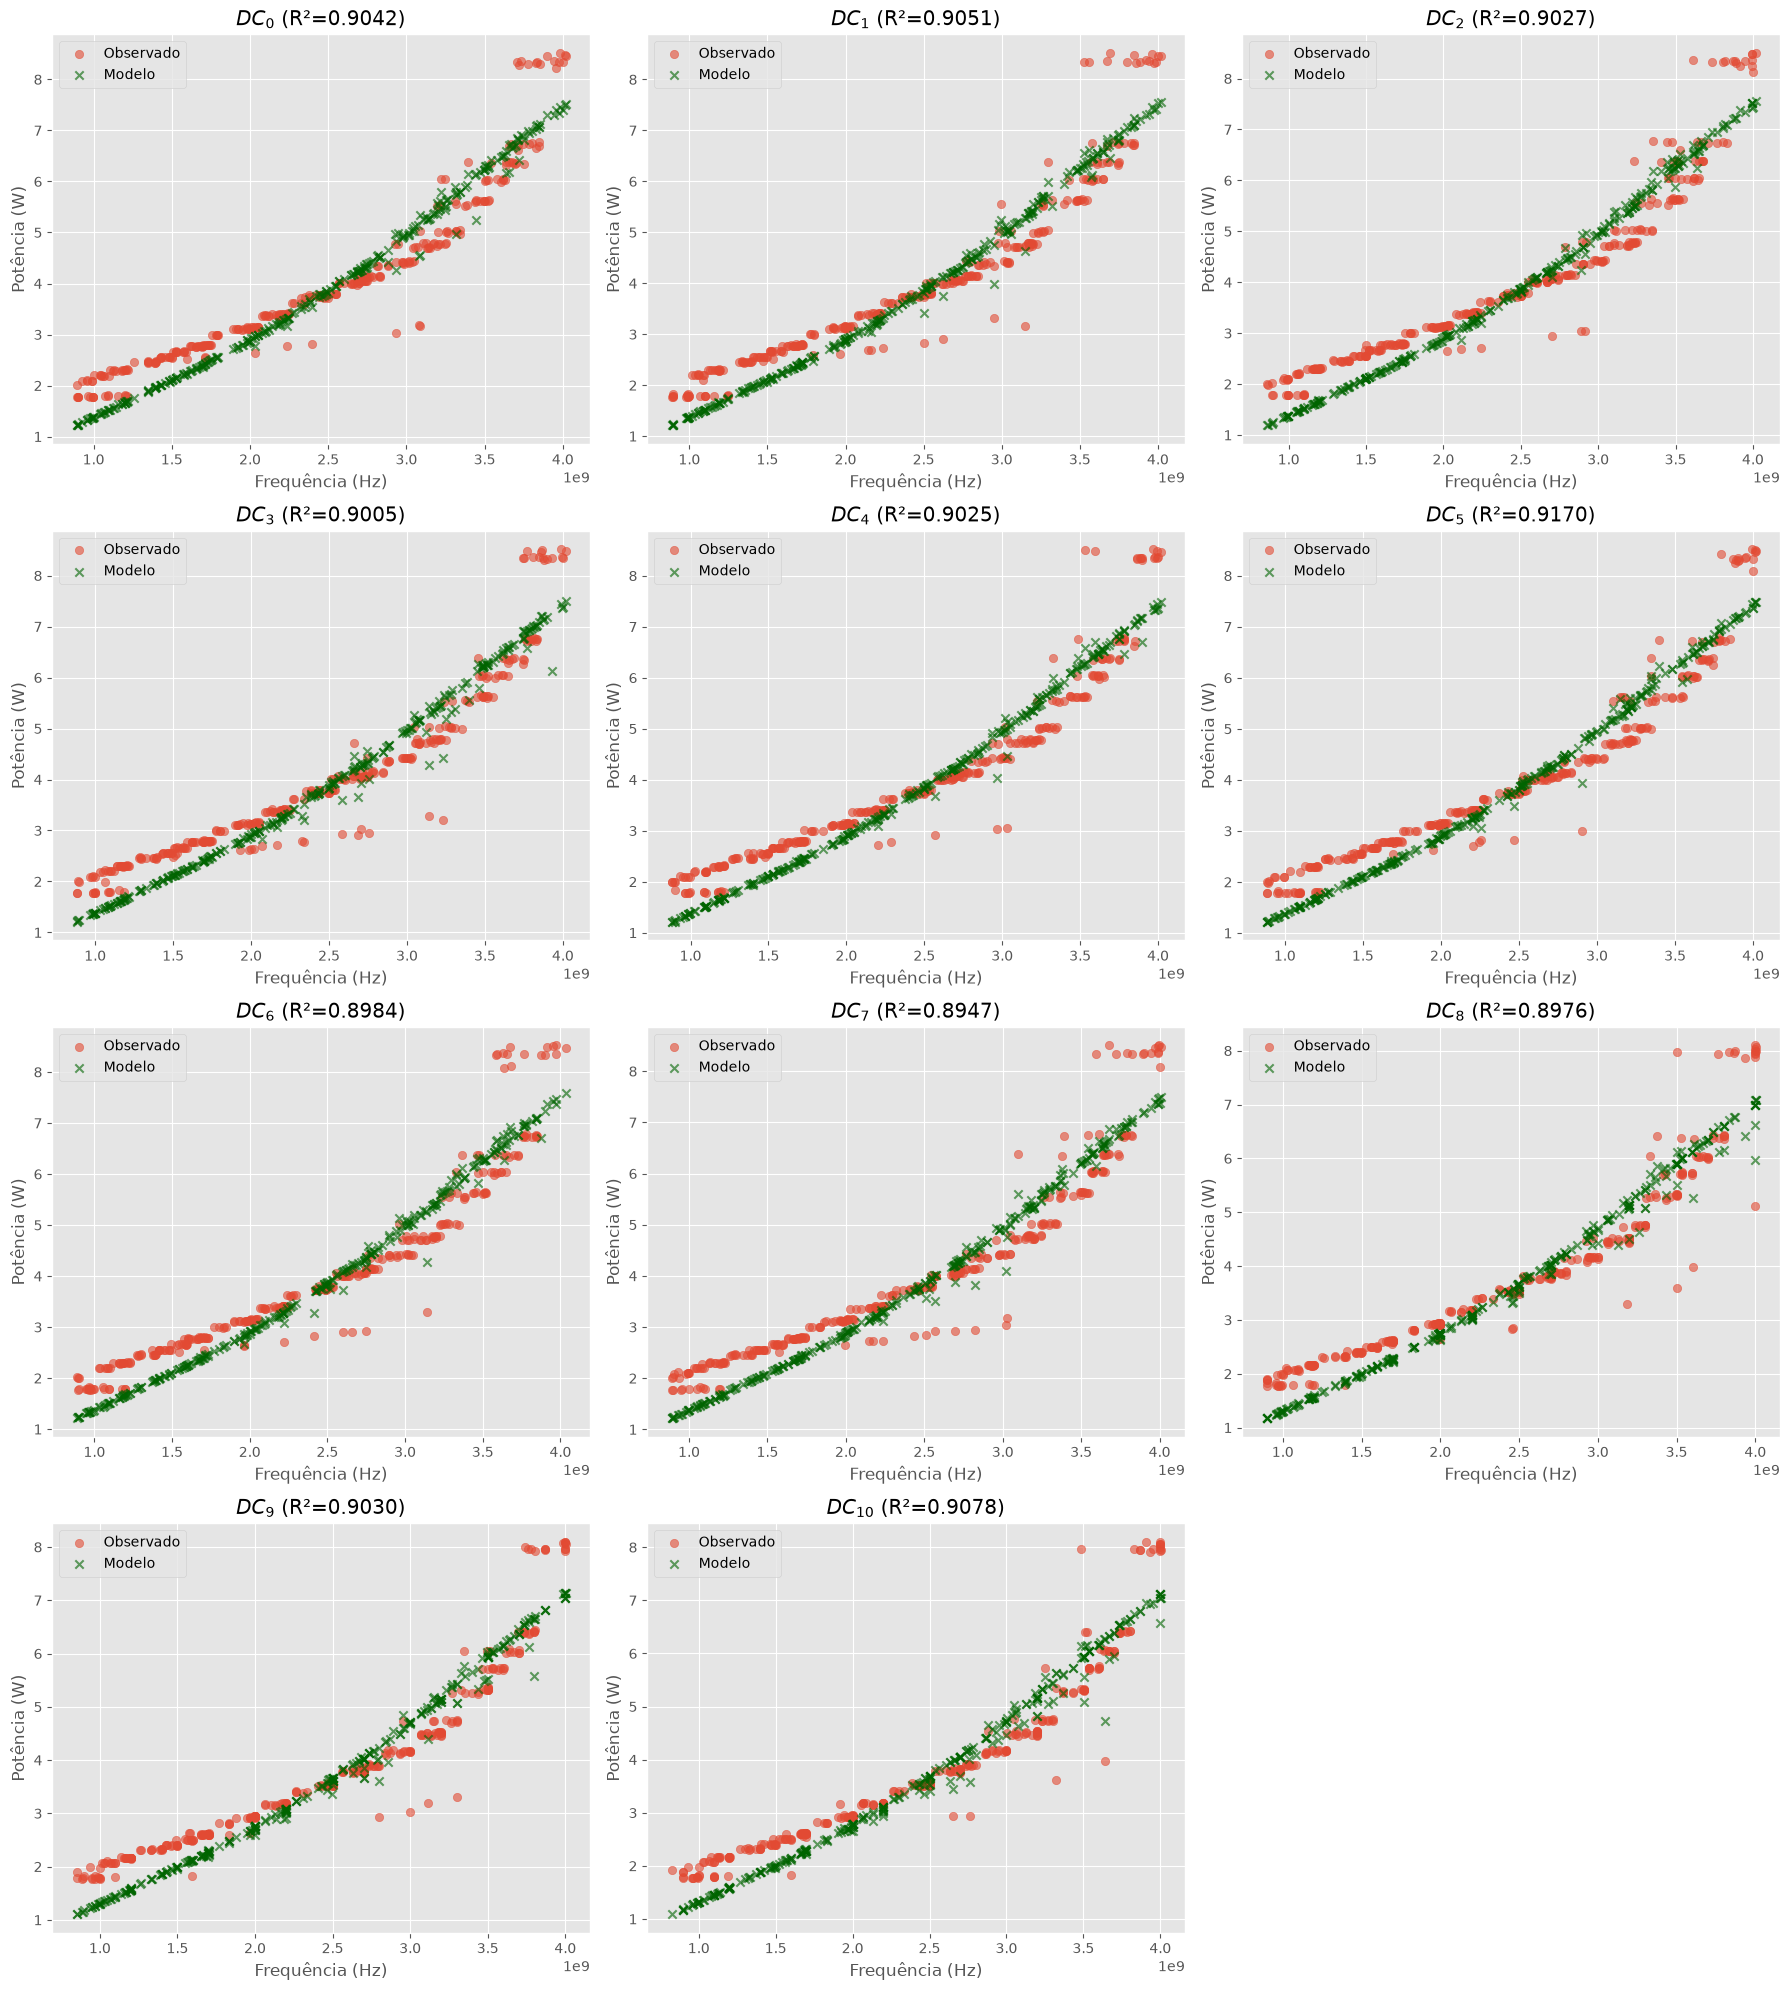

In [ ]:
if len(fit_results) > 0:
    fitted_stations = list(fit_results.keys())
    n_fitted = len(fitted_stations)
    cols_plot = 3
    rows_plot = math.ceil(n_fitted / cols_plot)
    
    fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(18, 5 * rows_plot))
    axes = axes.flatten() if n_fitted > 1 else [axes]
    
    for idx, i in enumerate(fitted_stations):
        ax = axes[idx]
        df_i = df_sta[i]
        
        P_obs = (df_i[f'host_consumption_sta{i}'] / df_i[f'training_time_sta{i}']).values.astype(float)
        f_data = df_i[f'cpu_freq_mean_sta{i}'].values.astype(float)
        V_data = df_i[f'cpu_voltage_sta{i}'].values.astype(float)
        
        P_pred = power_model((f_data, V_data), fit_results[i]['alpha'], fit_results[i]['gamma'])
        
        # Ordenar por frequência para visualização
        sort_idx = np.argsort(f_data)
        
        ax.scatter(f_data, P_obs, alpha=0.6, label='Observado', zorder=2)
        ax.scatter(f_data[sort_idx], P_pred[sort_idx], alpha=0.6, color='darkgreen', marker='x', label='Ajuste', zorder=3)
        ax.set_title(f'$DC_{{{i}}}$ (R²={fit_results[i]["R2"]:.4f})')
        ax.set_xlabel('Frequência (Hz)')
        ax.set_ylabel('Potência (W)')
        ax.legend()
    
    for idx in range(n_fitted, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig('fit_alpha_plot_3.eps', format='eps', bbox_inches='tight')
    plt.show()
else:
    print("Nenhum ajuste bem-sucedido para plotar.")

## 7. Salvar Resultados
Atualiza as constantes com os novos valores baseados nas calibrações em um novo arquivo JSON `sta_const_calibrado.json`.

In [9]:
json_path = '../sta_const.json'
if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        sta_const = json.load(f)
    
    # Substituir apenas onde conseguiu calibrar com sucesso (valores > 0)
    for i in range(N):
        if alpha_calibrated[i] > 0:
            sta_const['alpha'][i] = round(alpha_calibrated[i],12)
    
    sta_const['gamma'] = gamma_calibrated.tolist()
    
    with open('../sta_const_calibrado.json', 'w') as f:
        json.dump(sta_const, f, indent=2)
    
    print("Constantes calibradas salvas em 'sta_const_calibrado.json'")
else:
    print(f"Arquivo base {json_path} não encontrado.")

Constantes calibradas salvas em 'sta_const_calibrado.json'
